In [1]:
# T1. 读入数据，看看长什么样
# 提示：路径改成你的实际路径；如果报编码错误，加参数 encoding="utf-8-sig"
import pandas as pd
df = pd.read_csv(r"C:\Users\ASUS\WorkBuddy\2026-09-16-20-59-28\Project\data\sales_data.csv")
# 打印 df.shape 和 df.head()
print(df.shape)
df.head()


(1225, 9)


,订单编号,下单日期,商品类别,商品名称,单价,数量,支付方式,是否会员,销售额
0,SO2026000598,2025-10-31,家居生活,保温杯,50.2,1,微信支付,否,50.2
1,SO2026000557,2025-12-09,图书文具,文具套装,48.5,1,支付宝,是,48.5
2,SO2026000107,2026-01-15,食品饮料,坚果礼盒,97.1,2,银行卡,是,194.2
3,SO2026000418,2026-02-07,食品饮料,坚果礼盒,120.4,3,支付宝,否,361.2
4,SO2026000594,2026-08-27,数码电子,无线耳机,393.8,1,货到付款,否,393.8


In [2]:
# T2. 数据体检：用 df.info() 回答——一共几列？哪几列有缺失？各缺几条？
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1225 entries, 0 to 1224
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   订单编号    1225 non-null   object 
 1   下单日期    1225 non-null   object 
 2   商品类别    1225 non-null   object 
 3   商品名称    1225 non-null   object 
 4   单价      1225 non-null   float64
 5   数量      1225 non-null   int64  
 6   支付方式    1215 non-null   object 
 7   是否会员    1225 non-null   object 
 8   销售额     1204 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 86.3+ KB


In [3]:
# T3. 描述统计：销售额列的平均值、最大值、最小值是多少？
# 提示：先 df["销售额"] 选中一列，再 .mean() / .max() / .min()
df["销售额"]
print(df["销售额"].mean())
print(df["销售额"].max())
print(df["销售额"].min())

270.25448504983393
2130.8
13.4


In [4]:
# T4. 类别盘点：5 个商品类别各有多少订单？（提示：value_counts()）
df["商品类别"]
df["商品类别"].value_counts()


商品类别
食品饮料    275
服饰鞋包    243
图书文具    242
家居生活    238
数码电子    227
Name: count, dtype: int64

In [5]:
# T5. 条件筛选：单价超过 200 元的订单有几条？
# 其中销售额最大的那一单，卖的是什么商品、金额多少？
# 提示：df[df["单价"] > 200] 是筛选写法，先用它试试

df.groupby("商品类别")["销售额"].sum().sort_values(ascending=False)
df[df["单价"] > 200].max()

订单编号    SO2026001195
下单日期      2026-08-29
商品类别            服饰鞋包
商品名称             运动鞋
单价             495.7
数量                 7
支付方式             银行卡
是否会员               是
销售额           2130.8
dtype: object

In [6]:

df2 = df[df["销售额"]>200]
df2["销售额"].max()
df2[df2["销售额"] == df2["销售额"].max()]

,订单编号,下单日期,商品类别,商品名称,单价,数量,支付方式,是否会员,销售额
435,SO2026000908,2026-06-15,服饰鞋包,运动鞋,304.4,7,货到付款,否,2130.8


In [7]:
# T6. 挑战题（选做）：这份"脏数据"里完全重复的行有几条？（提示：搜一下 duplicated）
df[df.duplicated()]

,订单编号,下单日期,商品类别,商品名称,单价,数量,支付方式,是否会员,销售额
117,SO2026000161,2025-10-12,数码电子,充电宝,123.1,1,支付宝,是,123.1
131,SO2026000557,2025-12-09,图书文具,文具套装,48.5,1,支付宝,是,48.5
246,SO2026000873,2025-09-08,家居生活,台灯,130.6,2,微信支付,是,261.2
256,SO2026000356,2025-10-14,食品饮料,坚果礼盒,79.7,4,支付宝,是,318.8
307,SO2026000419,2026-02-03,数码电子,充电宝,77.1,2,微信支付,是,NaN
357,SO2026001181,2026-04-25,数码电子,无线耳机,301.5,2,支付宝,否,603.0
380,SO2026000585,2026-01-20,家居生活,保温杯,81.7,2,银行卡,是,163.4
469,SO2026000957,2025-10-14,家居生活,保温杯,53.1,1,银行卡,是,53.1
498,SO2026000919,2025-10-10,数码电子,充电宝,85.2,2,微信支付,是,170.4
510,SO2026000484,2025-09-30,家居生活,保温杯,91.5,1,支付宝,否,91.5


In [8]:
df = df.drop_duplicates()
df.shape
df.duplicated().sum()

np.int64(0)

In [9]:
df[df["销售额"].isnull()]

,订单编号,下单日期,商品类别,商品名称,单价,数量,支付方式,是否会员,销售额
28,SO2026000909,2026-04-06,服饰鞋包,T恤,113.5,5,微信支付,否,NaN
36,SO2026000419,2026-02-03,数码电子,充电宝,77.1,2,微信支付,是,NaN
137,SO2026000470,2026-05-23,食品饮料,代餐奶昔,92.8,2,银行卡,是,NaN
199,SO2026000049,2026-03-30,家居生活,台灯,189.2,3,银行卡,是,NaN
236,SO2026000078,2025-09-21,家居生活,台灯,77.9,4,微信支付,是,NaN
247,SO2026000674,2026-02-13,食品饮料,咖啡豆,101.6,1,支付宝,是,NaN
369,SO2026000275,2026-04-30,家居生活,保温杯,45.0,1,支付宝,是,NaN
456,SO2026000311,2026-06-28,图书文具,文具套装,20.6,3,支付宝,是,NaN
476,SO2026000651,2025-11-25,图书文具,畅销小说,52.2,5,微信支付,否,NaN
513,SO2026000082,2026-07-19,食品饮料,代餐奶昔,110.8,2,支付宝,否,NaN


In [10]:
df["销售额"] = df["销售额"].fillna(df["单价"]*df["数量"])

In [11]:
print(df["销售额"].isnull().sum())
print(df["销售额"].mean())
print(df.shape)

0
272.93666666666667
(1200, 9)


In [12]:
df["支付方式"] = df["支付方式"].fillna("未知")
df["支付方式"].isnull().sum()
df["支付方式"].value_counts()

支付方式
支付宝     510
微信支付    451
银行卡     176
货到付款     53
未知       10
Name: count, dtype: int64

In [13]:
df[df["数量"]<0]

,订单编号,下单日期,商品类别,商品名称,单价,数量,支付方式,是否会员,销售额
46,SO2026000659,2026-08-24,图书文具,畅销小说,56.4,-1,微信支付,否,56.4
51,SO2026000013,2025-10-27,家居生活,台灯,133.2,-1,支付宝,是,399.6
101,SO2026000133,2026-07-15,家居生活,保温杯,43.7,-1,微信支付,否,131.1
351,SO2026000376,2025-10-15,数码电子,充电宝,82.7,-1,微信支付,是,248.1
625,SO2026000906,2026-07-07,图书文具,畅销小说,38.7,-1,微信支付,是,38.7


In [14]:
df.loc[df["数量"] < 0,"数量"] = (df["销售额"] / df["单价"]).round()

In [15]:
df["数量"] = df["数量"].astype(int)   # 除法会把整列变成 3.0 这种小数格式，转回整数
df[df["数量"] < 0]        # 应该输出空表——负数清零
df["数量"].min()          # 应该输出 1——全店最小购买量恢复正常



1

In [16]:
df["商品名称"].value_counts()

商品名称
代餐奶昔        94
坚果礼盒        90
收纳盒         88
笔记本         86
文具套装        85
台灯          82
咖啡豆         82
T恤          80
双肩包         80
运动鞋         80
充电宝         77
无线耳机        76
畅销小说        69
智能手环        64
保温杯         59
  充电宝        4
  坚果礼盒       2
  保温杯        1
  运动鞋        1
Name: count, dtype: int64

In [17]:
df["商品名称"] = df["商品名称"].str.strip()

In [18]:
df["商品名称"].value_counts()

商品名称
代餐奶昔    94
坚果礼盒    92
收纳盒     88
笔记本     86
文具套装    85
台灯      82
咖啡豆     82
充电宝     81
运动鞋     81
T恤      80
双肩包     80
无线耳机    76
畅销小说    69
智能手环    64
保温杯     60
Name: count, dtype: int64

In [19]:
df["下单日期"] = pd.to_datetime(df["下单日期"])


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1200 entries, 0 to 1224
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   订单编号    1200 non-null   object        
 1   下单日期    1200 non-null   datetime64[ns]
 2   商品类别    1200 non-null   object        
 3   商品名称    1200 non-null   object        
 4   单价      1200 non-null   float64       
 5   数量      1200 non-null   int64         
 6   支付方式    1200 non-null   object        
 7   是否会员    1200 non-null   object        
 8   销售额     1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 126.0+ KB


In [22]:
df.to_csv(r"E:\WorkBuddy\Project\data\cleaned_sales.csv", index=False, encoding="utf-8-sig")

In [23]:
check = pd.read_csv(r"E:\WorkBuddy\Project\data\cleaned_sales.csv")
check.shape        # 应该输出 (1200, 9)


(1200, 9)

In [26]:
df["月份"] = df["下单日期"].dt.month
df.head()

,订单编号,下单日期,商品类别,商品名称,单价,数量,支付方式,是否会员,销售额,月份
0,SO2026000598,2025-10-31,家居生活,保温杯,50.2,1,微信支付,否,50.2,10
1,SO2026000557,2025-12-09,图书文具,文具套装,48.5,1,支付宝,是,48.5,12
2,SO2026000107,2026-01-15,食品饮料,坚果礼盒,97.1,2,银行卡,是,194.2,1
3,SO2026000418,2026-02-07,食品饮料,坚果礼盒,120.4,3,支付宝,否,361.2,2
4,SO2026000594,2026-08-27,数码电子,无线耳机,393.8,1,货到付款,否,393.8,8


In [32]:
df.groupby("月份")["销售额"].sum()

月份
1     21635.0
2     24959.7
3     25856.5
4     31786.7
5     24710.9
6     46423.3
7     27904.4
8     26445.2
9     23105.7
10    22411.5
11    33534.5
12    18750.6
Name: 销售额, dtype: float64

In [35]:
df.groupby("商品类别")["销售额"].sum().sort_values(ascending = False)

商品类别
服饰鞋包    114181.0
数码电子     91112.3
食品饮料     60607.5
家居生活     42061.9
图书文具     19561.3
Name: 销售额, dtype: float64

In [36]:
df["商品类别"].value_counts()

商品类别
食品饮料    268
服饰鞋包    241
图书文具    240
家居生活    230
数码电子    221
Name: count, dtype: int64

In [37]:
df.groupby("商品名称")["销售额"].sum().sort_values(ascending = False).head(5)

商品名称
运动鞋     65784.8
无线耳机    43514.7
双肩包     33177.2
智能手环    30845.4
代餐奶昔    26490.6
Name: 销售额, dtype: float64

In [39]:
df.groupby("是否会员")["销售额"].agg(["count","mean","sum"])

,count,mean,sum
是否会员,,,
否,582,281.789175,164001.3
是,618,264.599838,163522.7


In [40]:
df["支付方式"].value_counts()

支付方式
支付宝     510
微信支付    451
银行卡     176
货到付款     53
未知       10
Name: count, dtype: int64

<Axes: title={'center': '月度销售额趋势'}, xlabel='月份'>

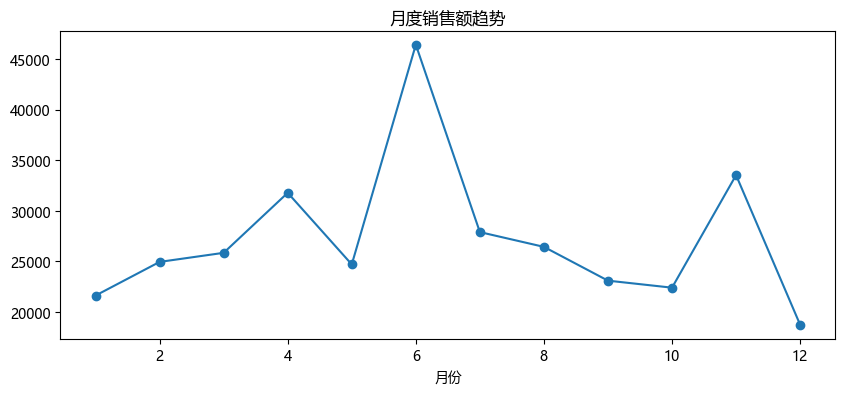

In [41]:
#数据可视化处理
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

monthly = df.groupby("月份")["销售额"].sum()
monthly.plot(kind = "line",marker="o",figsize=(10,4),title="月度销售额趋势")

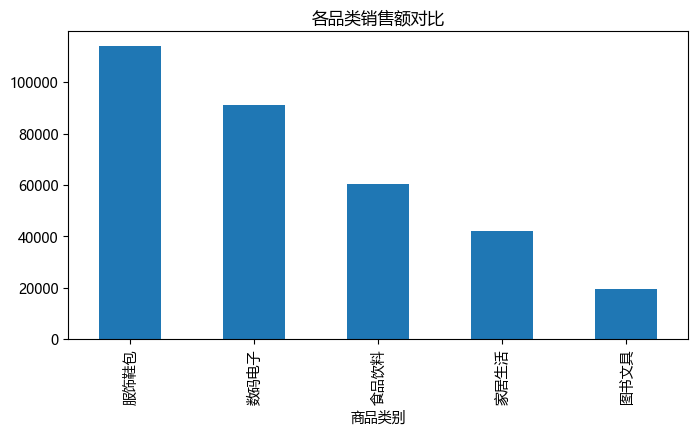

In [52]:
cat = df.groupby("商品类别")["销售额"].sum().sort_values(ascending=False)
cat.plot(kind="bar",figsize=(8,4),title="各品类销售额对比")
plt.savefig(r"E:\WorkBuddy\Project\my_charts\02_各品类销售对比.png", dpi=150, bbox_inches="tight")

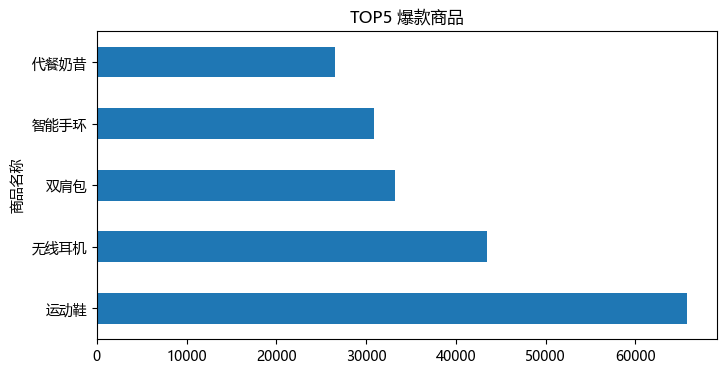

In [53]:
top5 = df.groupby("商品名称")["销售额"].sum().sort_values(ascending=False).head(5)
top5.plot(kind="barh", figsize=(8, 4), title="TOP5 爆款商品")
plt.savefig(r"E:\WorkBuddy\Project\my_charts\03_爆款商品.png", dpi=150, bbox_inches="tight")

In [46]:
(cat.iloc[0] + cat.iloc[1]) / cat.sum()

np.float64(0.6268038372760469)

In [47]:
df[df["商品名称"] == "运动鞋"].shape[0]          # 运动鞋一共几单？
2130.8 / df[df["商品名称"] == "运动鞋"]["销售额"].sum()   # 神单占运动鞋总销售额的比例

np.float64(0.032390461018350754)

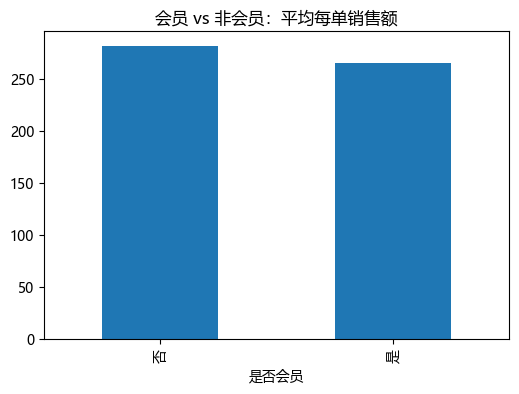

In [54]:
member_mean = df.groupby("是否会员")["销售额"].mean()
member_mean.plot(kind="bar", figsize=(6, 4), title="会员 vs 非会员：平均每单销售额")
plt.savefig(r"E:\WorkBuddy\Project\my_charts\04_会员销售情况.png", dpi=150, bbox_inches="tight")

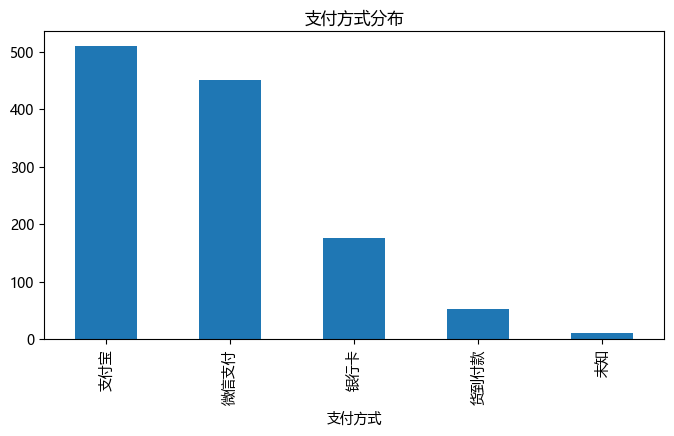

In [55]:
df["支付方式"].value_counts().plot(kind="bar", figsize=(8, 4), title="支付方式分布")
plt.savefig(r"E:\WorkBuddy\Project\my_charts\05_支付方式分布.png", dpi=150, bbox_inches="tight")

In [50]:
import os
os.makedirs(r"E:\WorkBuddy\Project\my_charts", exist_ok=True)
